<a href="https://colab.research.google.com/github/gopikaramalingam31-ops/Gopika-spotify-minor-project/blob/main/cardiovascular_disease_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  
(70000, 13)
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64
Before duplicates: (70000, 13)
After duplicates: (70000, 13)
   age  gender  height  weight  ap_hi  ap_lo  cholestero

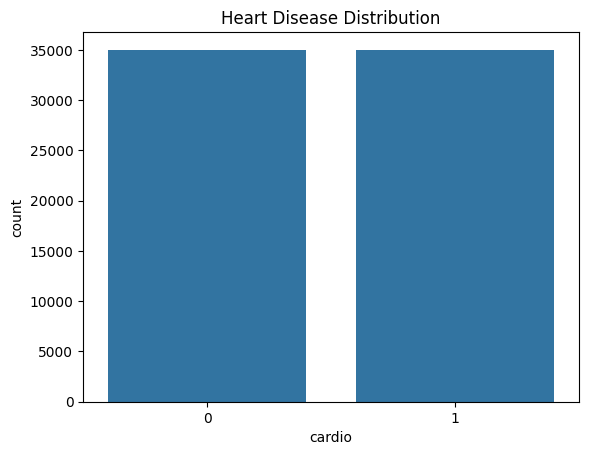

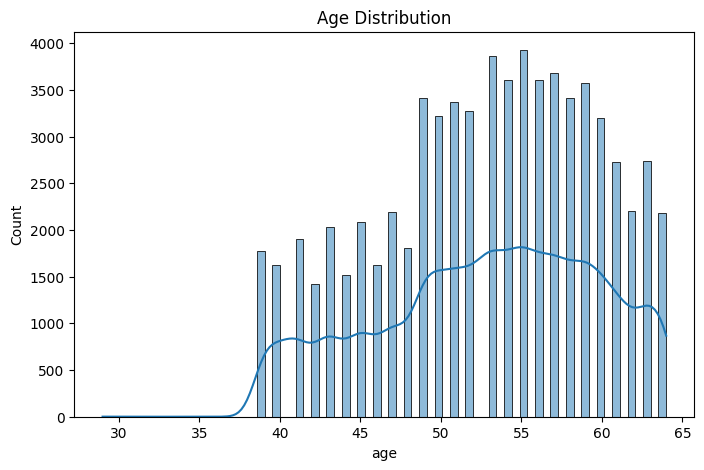

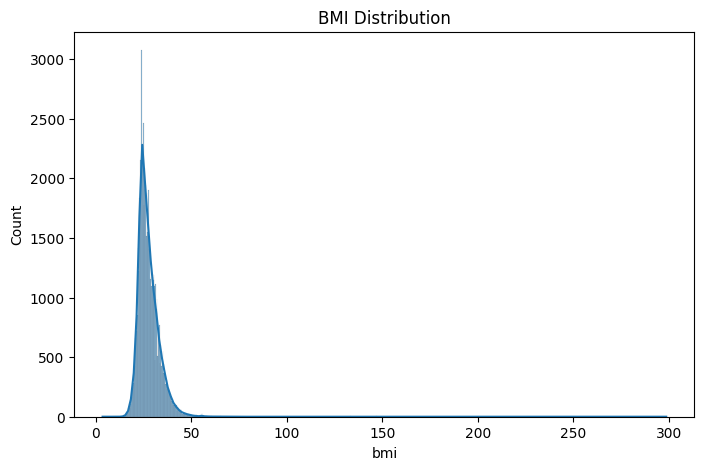

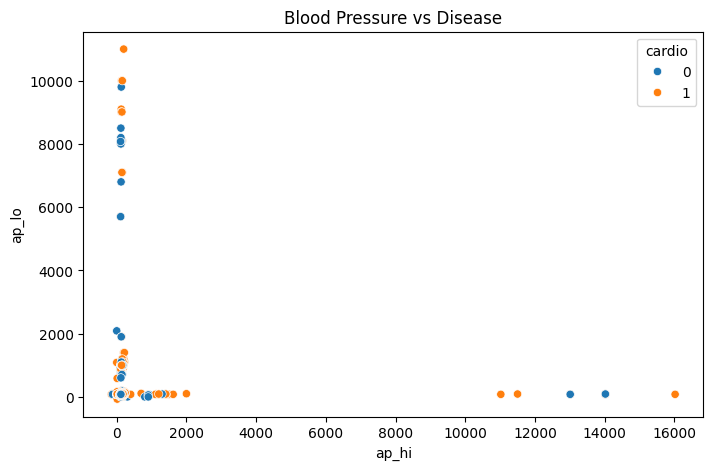

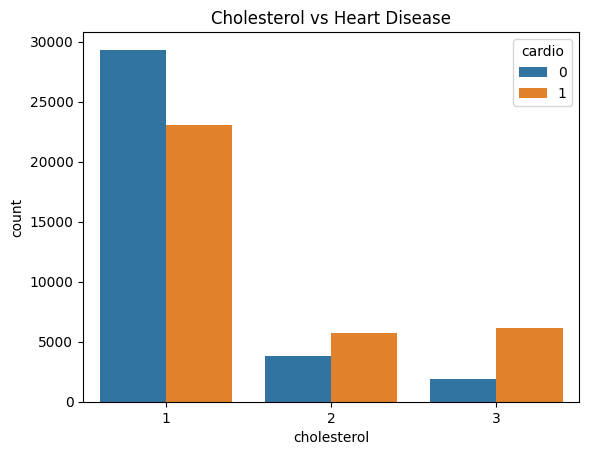

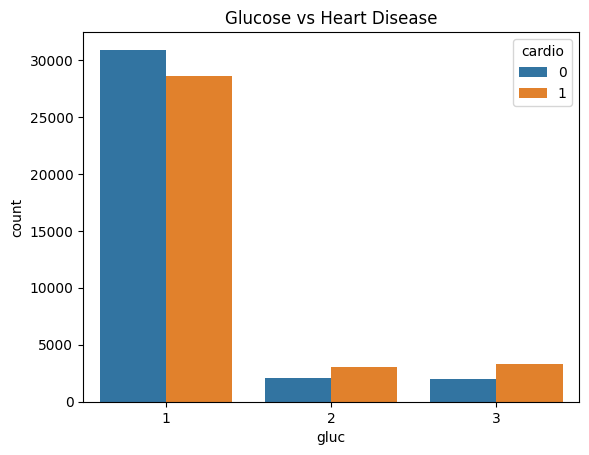

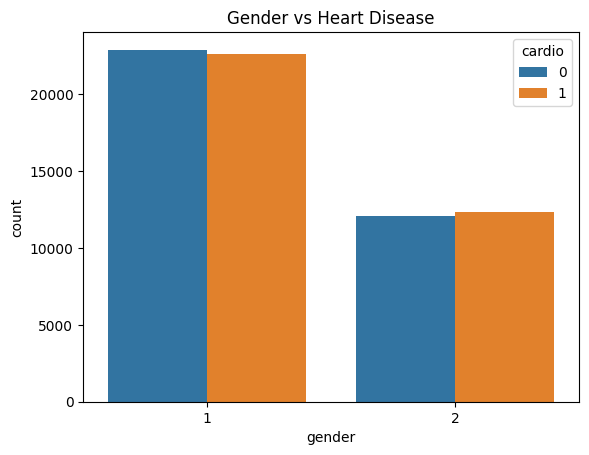

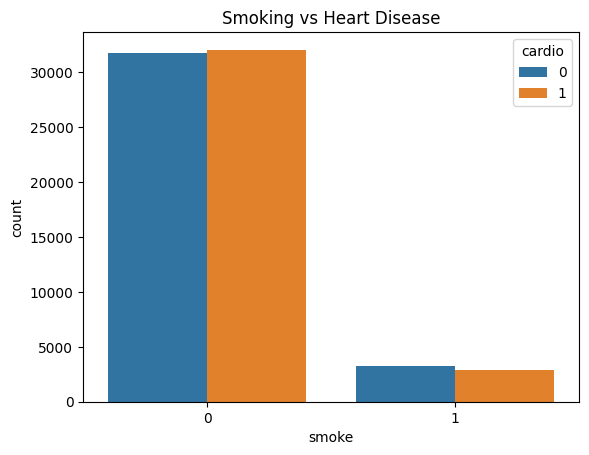

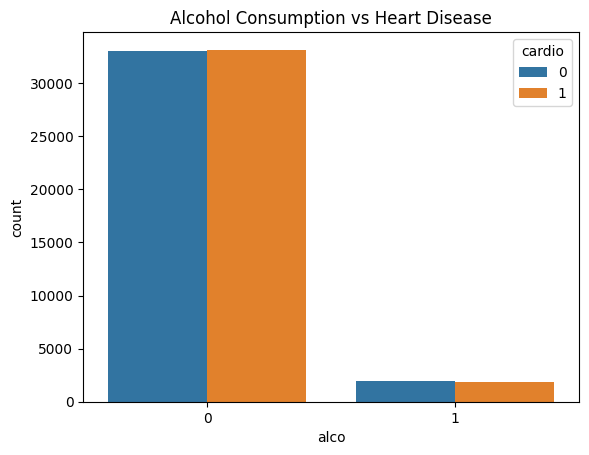

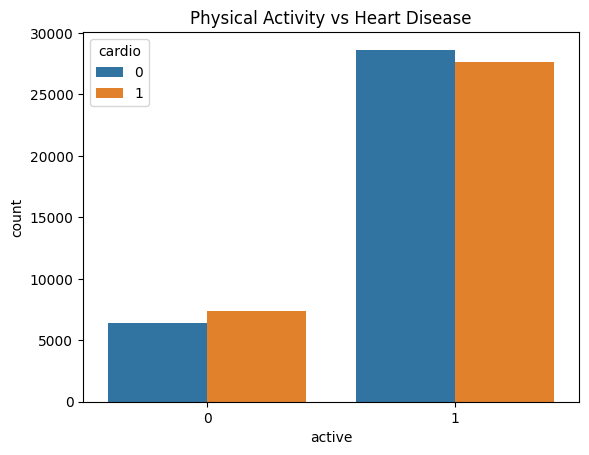

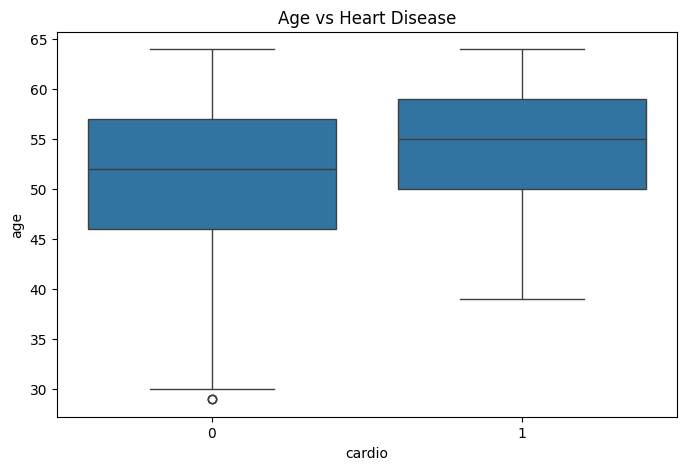

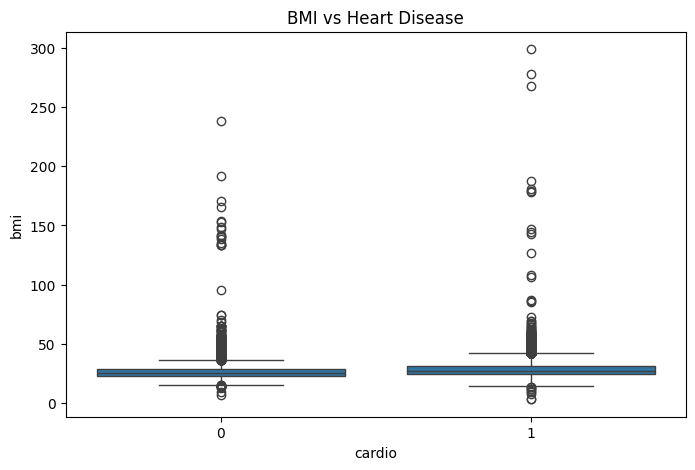

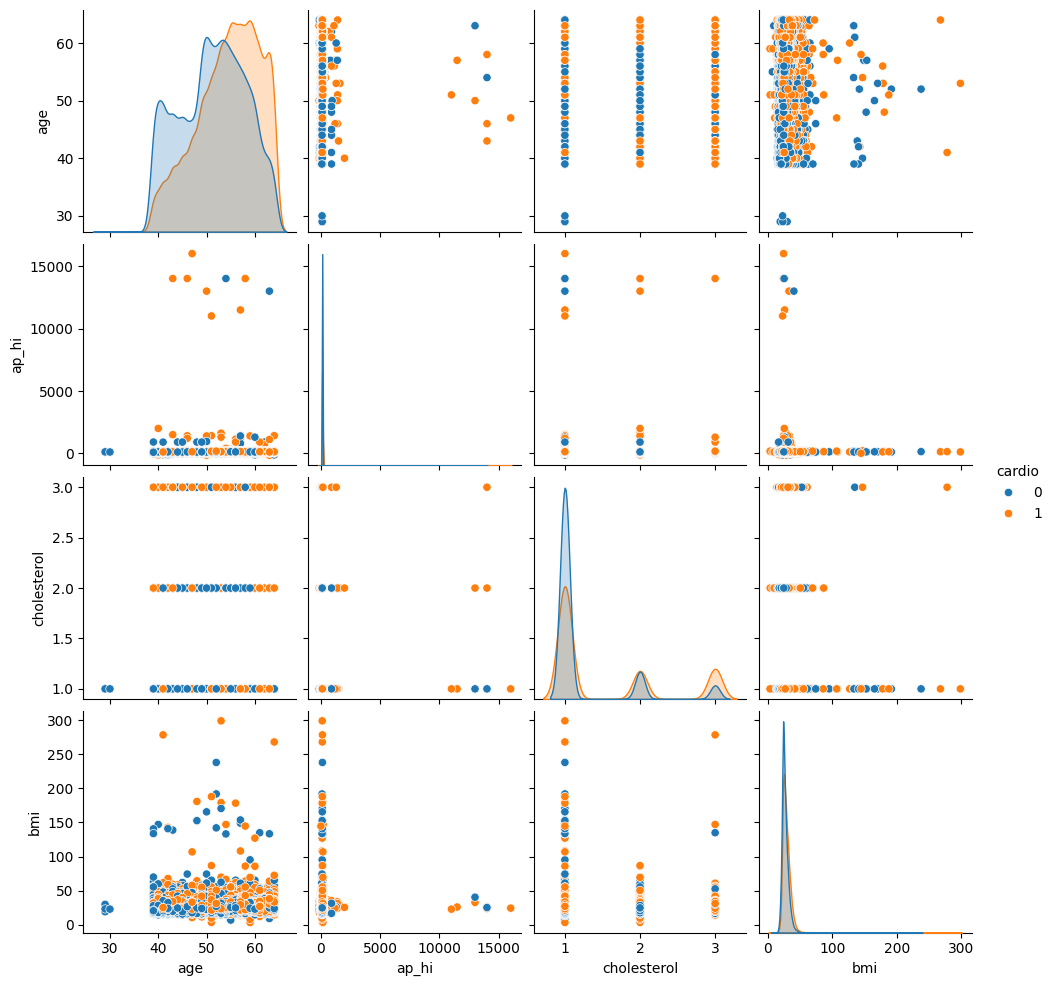

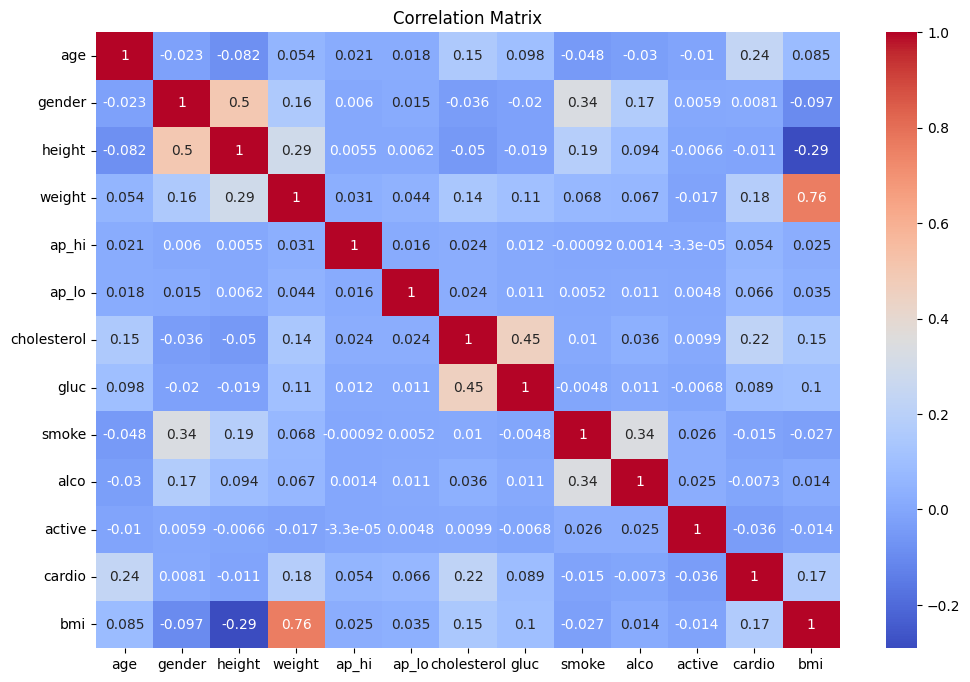

SVM Accuracy: 73.36%
KNN Accuracy: 64.71%
Decision Tree Accuracy: 63.84%
Logistic Regression Accuracy: 72.33%
Random Forest Accuracy: 70.91%


In [ ]:
# Project 1: Cardiovascular Disease Prediction


# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier



# load dataset
_df = pd.read_csv('/content/cardio.csv', sep=';')
print(_df.head())
print(_df.shape)


# 4) Data Preprocessing
df = _df.copy()

print(df.isnull().sum())

print('Before duplicates:', df.shape)
df = df.drop_duplicates()
print('After duplicates:', df.shape)


df['age'] = (df['age'] / 365).astype(int)

df['height_m'] = df['height'] / 100
df['bmi'] = df['weight'] / (df['height_m'] ** 2)

# drop unnecessary columns
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
if 'height_m' in df.columns:
    df.drop('height_m', axis=1, inplace=True)

print(df.head())




# Exploratory Data Analysis and Visualizations

# Target Variable Count Plot

sns.countplot(x='cardio', data=df)
plt.title('Heart Disease Distribution')
plt.show()


# Age Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.show()


# BMI Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['bmi'], kde=True)
plt.title('BMI Distribution')
plt.show()


# Blood Pressure Analysis

plt.figure(figsize=(8,5))
sns.scatterplot(x='ap_hi', y='ap_lo', hue='cardio', data=df)
plt.title('Blood Pressure vs Disease')
plt.show()


# Cholesterol vs Disease

sns.countplot(x='cholesterol', hue='cardio', data=df)
plt.title('Cholesterol vs Heart Disease')
plt.show()


# Glucose vs Disease

sns.countplot(x='gluc', hue='cardio', data=df)
plt.title('Glucose vs Heart Disease')
plt.show()

# Gender vs Disease

sns.countplot(x='gender', hue='cardio', data=df)
plt.title('Gender vs Heart Disease')
plt.show()


# Smoking vs Disease

sns.countplot(x='smoke', hue='cardio', data=df)
plt.title('Smoking vs Heart Disease')
plt.show()


# Alcohol vs Disease

sns.countplot(x='alco', hue='cardio', data=df)
plt.title('Alcohol Consumption vs Heart Disease')
plt.show()


# Physical Activity vs Disease

sns.countplot(x='active', hue='cardio', data=df)
plt.title('Physical Activity vs Heart Disease')
plt.show()


# Box Plot for Age

plt.figure(figsize=(8,5))
sns.boxplot(x='cardio', y='age', data=df)
plt.title('Age vs Heart Disease')
plt.show()


# Box Plot for BMI

plt.figure(figsize=(8,5))
sns.boxplot(x='cardio', y='bmi', data=df)
plt.title('BMI vs Heart Disease')
plt.show()


# Pair Plot (Important Features)

sns.pairplot(df[['age', 'ap_hi', 'cholesterol', 'bmi', 'cardio']], hue='cardio')
plt.show()


# Correlation Matrix

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


# 7) Feature Selection

X = df.drop('cardio', axis=1)
y = df['cardio']


# Train Test Split

xtrain, xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Feature Scaling

scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)


# Apply Machine Learning Algorithms

models = {
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(xtrain, ytrain)
    pred = model.predict(xtest)
    acc = accuracy_score(ytest, pred)
    results[name] = acc
    print(f'{name} Accuracy: {acc*100:.2f}%')


#  ROC Curve Analysis

from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

for name, model in models.items():

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(xtest)[:, 1]
    else:
        y_prob = model.decision_function(xtest)

    fpr, tpr, _ = roc_curve(ytest, y_prob)
    auc_score = roc_auc_score(ytest, y_prob)
    plt.plot(fpr, tpr, label=f'{name} AUC = {auc_score:.2f}')

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for ML Models')
plt.legend()
plt.show()


#  Accuracy Comparison Graph

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
plt.show()




# Best Model Building

best_model = RandomForestClassifier(random_state=42)
best_model.fit(xtrain, ytrain)

final_pred = best_model.predict(xtest)

print('Final Accuracy:', accuracy_score(ytest, final_pred)*100)
print(confusion_matrix(ytest, final_pred))
print(classification_report(ytest, final_pred))

